# IAEA API to access Gamma energies and intensities

This Notebook is based on the IAEA example here:
https://iaea-nds.github.io/lc_api_notebook/

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# the service URL
livechart = "https://nds.iaea.org/relnsd/v1/data?"

# There have been cases in which the service returns an HTTP Error 403: Forbidden
# use this workaround
import urllib.request
def lc_pd_dataframe(url):
    req = urllib.request.Request(url)
    req.add_header('User-Agent', 'Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:77.0) Gecko/20100101 Firefox/77.0')
    return pd.read_csv(urllib.request.urlopen(req))

In [13]:
def getdf(nuclide="241am"):
    # we do not want to include metastable states at this point, ie. p_energy==0.
    _df = lc_pd_dataframe(livechart + f"fields=decay_rads&nuclides={nuclide}&rad_types=g").query("p_energy==0")
    _df = _df[pd.to_numeric(_df['intensity'],errors='coerce').notna()] # remove blanks (unknown intensities)
    _df.intensity = _df['intensity'].astype(float) # convert to numeric. Note how one can specify the field by attribute or by string
    return _df

## Plot γ energy vs intensity for Am-241 decay

fields=decay_rads specifies to retrieve the decay radiations, nuclides=241am specifies the parent of the decay (241am), rad_types=g for the radiation type (gamma).
On the plot below, mouseover the points to see the data. Zoom an pan are enabled, and the option to save as png is is activated when the mouse is over the top-right

## Important
For nuclides having metastable stable states one might want to filter the radiations coming only from the Ground State.
The energy of the parent is stored in the "p-energy" field. The dataframe below has the query option that makes the job
See below the full list of fields, and the API v0 guide for the full description of the fields 

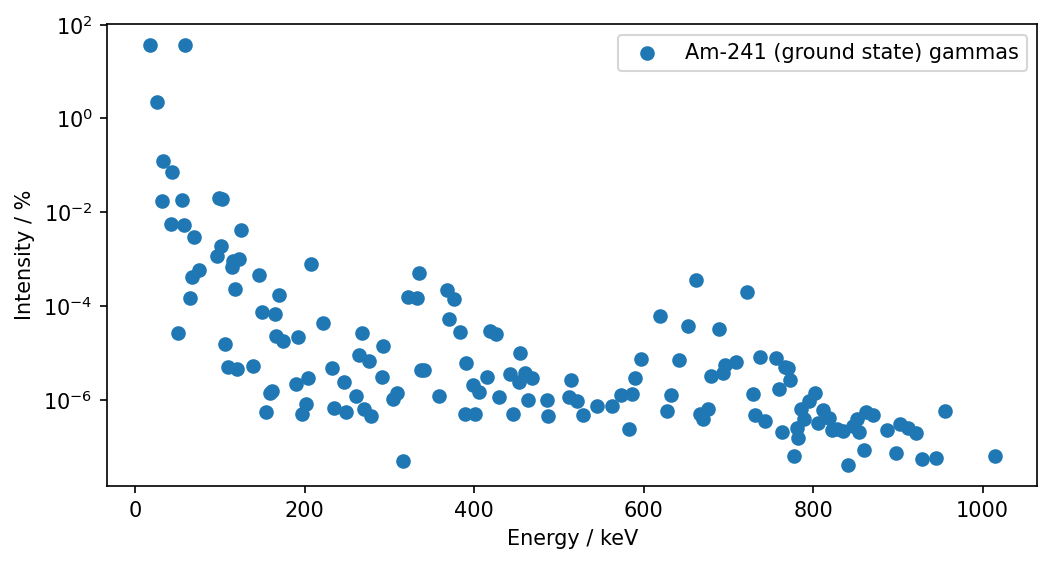

In [14]:
# load data into a dataframe 
#df = lc_pd_dataframe(livechart + "fields=decay_rads&nuclides=241am&rad_types=g").query("p_energy==0")
#df = df[pd.to_numeric(df['intensity'],errors='coerce').notna()] # remove blanks (unknown intensities)
#df.intensity = df['intensity'].astype(float) # convert to numeric. Note how one can specify the field by attribute or by string 

df = getdf(nuclide="241am")

fig, ax = plt.subplots(figsize=(8,4), dpi=150)
ax.scatter(df["energy"], df["intensity"], label="Am-241 (ground state) gammas")
ax.set_yscale("log")
ax.set_xlabel("Energy / keV")
ax.set_ylabel("Intensity / %")
plt.legend()
plt.show()

### alternative plotting option using dataframe.plot

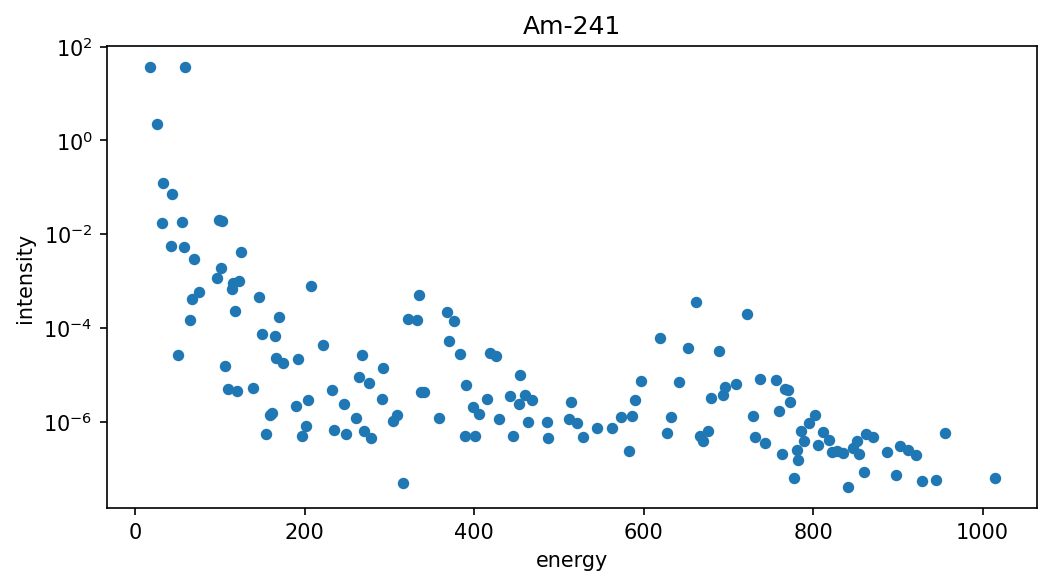

In [9]:
fig, ax = plt.subplots(figsize=(8,4), dpi=150)
df.plot(kind='scatter', x='energy', y='intensity', ax=ax, title="Am-241")
ax.set_yscale("log")
plt.show()

## And now the same for Tl-208

In [15]:
df_tl208 = getdf(nuclide="208tl")

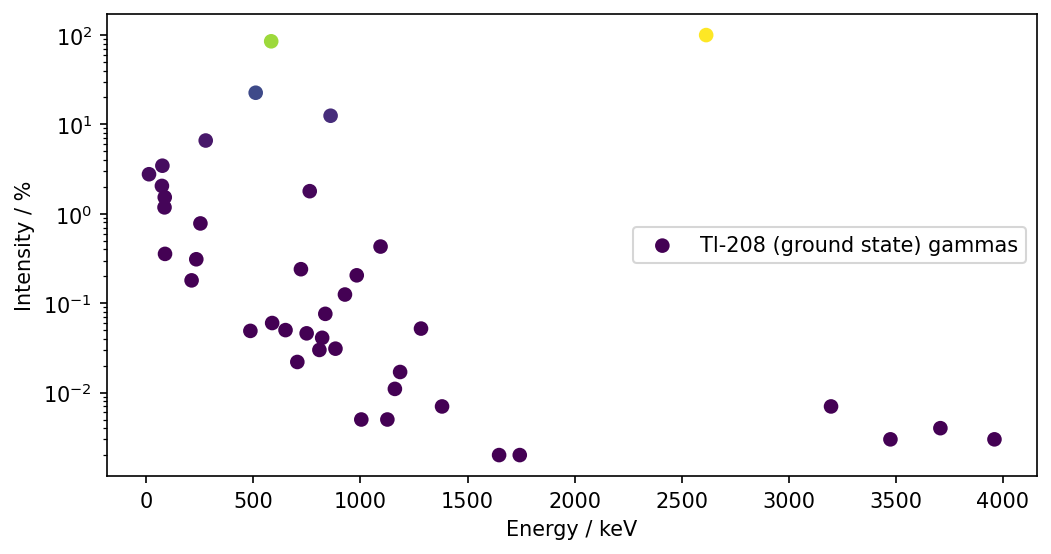

In [16]:
fig, ax = plt.subplots(figsize=(8,4), dpi=150)
ax.scatter(df_tl208["energy"], df_tl208["intensity"], label="Tl-208 (ground state) gammas", c=df_tl208["intensity"])
ax.set_yscale("log")
ax.set_xlabel("Energy / keV")
ax.set_ylabel("Intensity / %")
plt.legend()
plt.show()